<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_4_Macroeconomic_Credit_Stress_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Macroeconomic Credit Stress Testing: 9-Quarter Loss Projection for a Consumer Loan Portfolio**

Part 4 of the credit risk series. It requires the outputs of *Part 0: Credit Risk Data Foundation* and *Part 3: LGD Modeling*.

---

* Project Overview & Data Source

Data Source: This project uses the Lending Club loan [dataset](https://www.kaggle.com/datasets/wordsforthewise/lending-club), prepared in Part 0, together with state unemployment and US GDP data from [FRED](https://fred.stlouisfed.org/). The LGD satellite model estimated in Part 3 supplies the loss rate at default.

The Business Question: *How much of the loan book still performing at the snapshot date would be lost to defaults over the next 9 quarters if the economy entered a recession? Which segments, and which risk parameter (PD or LGD), drive the extra loss?*

A **stress test** asks *"what if?"* instead of *"what is most likely?"*. Supervisors use stress tests to check that banks hold enough capital to survive a severe but plausible recession: the Federal Reserve's DFAST/CCAR in the US, and OSFI's stress-testing expectations (Guideline E-18) in Canada. The same machinery also drives the multi-scenario expected credit loss under IFRS 9.

Objective: To build a **bottom-up credit stress test**: a macro-sensitive PD model, combined with the LGD satellite model and an amortizing EAD, that projects quarterly losses under baseline, adverse and severely adverse scenarios over the 9-quarter horizon used by the Fed.

---

* The Logic & Methodology

The pipeline follows the standard structure of a bank stress test:

Loan-Quarter Panel Construction: Each loan is expanded into one row per quarter at risk, with default and prepayment flags and the lagged state macro conditions. Censored loans are kept.

PD Satellite Model (Discrete-Time Hazard): A logistic hazard model estimates the probability of default in each quarter as a function of loan age (seasoning), borrower risk and lagged unemployment and GDP. A second hazard captures prepayment, a competing risk.

Out-of-Time Backtest: The model is re-estimated on earlier data and must predict the following 8 quarters' default rates. It is compared with a no-macro benchmark.

Scenario Design & Regional Downscaling: Three national scenarios (the severely adverse one peaks at 10% unemployment, like the Fed's 2025 scenario) are translated into state-level paths using each state's historical sensitivity to the national cycle.

Loss Projection Engine: Expected loss in each quarter is $\sum_i PD^{marg}_{it} \times LGD_{it} \times EAD_{it}$, with survival probabilities, scenario-dependent LGD and scheduled amortization.

Stress Analytics: Loss by scenario, a PD-vs-LGD decomposition, loss by grade, a sensitivity curve and a **reverse stress test**.

---

* Results & Business Impact

Portfolio: The stress test covers **873,780 current loans with $9.13 billion outstanding** at the March 2019 snapshot.

Scenario Losses: The baseline 9-quarter loss is **$868M (9.5% of the starting balance)**. The adverse scenario raises it only to **9.6%**, the severely adverse to **9.7% (1.02× baseline)**, and the realized 2019–21 COVID path to **10.1% (1.06×)**.

Key Finding: A recession that doubles unemployment barely moves projected losses. The model **fails validation**:
* the unemployment **level** coefficient has the wrong sign;
* the out-of-time backtest shows **no gain over a no-macro benchmark**;
* both models **under-predict defaults by 16%**.

The cause is identified: Lending Club's underwriting loosened while unemployment fell (2010–2018), and the model confuses the two trends. The stress results must therefore be read as a **lower bound**, and the model needs vintage controls or a management overlay before use.

What Works: Grade drives a 10× spread in stressed loss rates (2.9% for A to 32.4% for G). Grades C and D carry 60% of the dollar loss. The LGD channel from Part 3 contributes **40%** of the (small) stress add-on.

---

Tech Stack: Python, Pandas, NumPy, SciPy, Matplotlib, Google Colab.

# Step 1: Environment Setup & Data Loading
We mount Google Drive, load the loan table, the macro tables and the LGD satellite model, and define the settings of the stress test:

* `SAMPLE_LOANS`: the number of loans used to estimate the hazard models. Each loan becomes about 8 rows in the panel, so 150,000 loans gives roughly 1.2 million loan-quarters. That is comfortable for a standard Colab session.
* `CO_LAG_Q`: the estimation panel stops 2 quarters before the snapshot date. Defaults in those last months have not yet been charged off, so they would be missing from the data.
* `H = 9`: the projection horizon in quarters, as in the Fed's DFAST/CCAR exercises.

Dates are converted to integer **quarter numbers** (year × 4 + quarter − 1). This makes the lag and horizon arithmetic simple and fast.

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit, logit
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')
import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')

# 1.2. Stress-test settings
SAMPLE_LOANS = 150_000   # loans used to estimate the hazard models
CO_LAG_Q = 2             # censor the estimation panel 2 quarters before the snapshot
BACKTEST_Q = 8           # length of the out-of-time backtest window (quarters)
H = 9                    # projection horizon (quarters), as in DFAST/CCAR
RANDOM_STATE = 42

# 1.3. Load the Part 0 and Part 3 outputs
lc = pd.read_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))
macro_state = pd.read_csv(os.path.join(PROJECT_DIR, 'macro_state_q.csv'))
macro_us = pd.read_csv(os.path.join(PROJECT_DIR, 'macro_us_q.csv'))
with open(os.path.join(PROJECT_DIR, 'as_of.txt')) as f:
    AS_OF = pd.Period(f.read().strip(), 'M')
with open(os.path.join(PROJECT_DIR, 'lgd_satellite.json')) as f:
    lgd_sat = json.load(f)

# 1.4. Quarter-number helpers
def qn_from_month(s):
    """Period[M] Series -> integer quarter number (year*4 + q-1); NaN-safe."""
    return (s.dt.year * 4 + (s.dt.month - 1) // 3).where(s.notna())

def qn_from_str(s):
    p = pd.PeriodIndex(s, freq='Q')
    return np.asarray(p.year * 4 + p.quarter - 1)

def qlabel(qn):
    qn = int(qn)
    return f"{qn // 4}Q{qn % 4 + 1}"

macro_state['qn'] = qn_from_str(macro_state['quarter'])
macro_us['qn'] = qn_from_str(macro_us['quarter'])
AS_OF_QN = AS_OF.year * 4 + (AS_OF.month - 1) // 3
END_QN = AS_OF_QN - CO_LAG_Q
STATES = sorted(macro_state['state'].unique())

print(f"Loans loaded: {len(lc):,}")
print(f"Snapshot: {qlabel(AS_OF_QN)} | Estimation panel ends: {qlabel(END_QN)} | "
      f"Projection: {qlabel(AS_OF_QN + 1)} to {qlabel(AS_OF_QN + H)}")

Mounted at /content/drive
Loans loaded: 2,260,668
Snapshot: 2019Q1 | Estimation panel ends: 2018Q3 | Projection: 2019Q2 to 2021Q2


# Step 2: Loan-Quarter Panel Construction
The PD model in Part 1 answered one question: *will this loan ever default?* A stress test needs more than that:
* **Timing:** in *which quarter* does the default happen? Losses are projected quarter by quarter.
* **Time-varying drivers:** the economy changes during the life of a loan.
* **Seasoning:** default risk rises during the first year of a loan and then falls.
* **Censoring:** most loans have not finished, but they still carry information.

The solution is a **loan-quarter panel**. Each loan contributes one row for every quarter it was at risk, from age 1 until its exit or the censoring date:

| Exit type | Last row | Event flag in last row |
|---|---|---|
| Default (before panel end) | default quarter | `d_default = 1` |
| Prepaid (before panel end) | payoff quarter | `d_prepay = 1` |
| Matured | maturity quarter | none |
| Still open, or exit after panel end | panel end (censored) | none |

Each row is then linked to the economy of the borrower's state in the **previous** quarter:
* `ur_lag`: the unemployment level;
* `dur4_lag`: the 4-quarter change in unemployment;
* `gdp_lag`: US real GDP growth.

The one-quarter lag prevents the model from using same-quarter information and gives it a realistic reaction time.

--- Building the Loan-Quarter Panel ---
133,037 loans -> 849,045 loan-quarters
Defaults: 15,218 | Prepayments: 47,303 | Average quarterly default rate: 1.792%


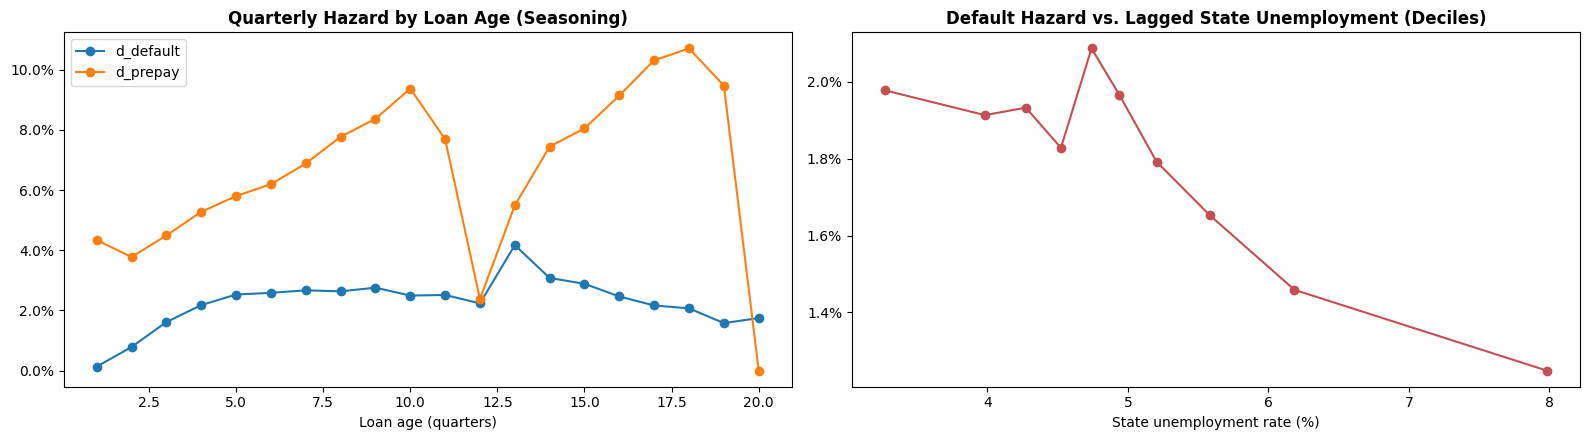

In [ ]:
print("--- Building the Loan-Quarter Panel ---")

# 1. Fast (state, quarter) -> macro lookup
class MacroCube:
    """Stores ur, ur_chg4 and gdp_growth as dense state x quarter arrays for fast lookups."""
    def __init__(self, long):
        self.q0 = int(long['qn'].min())
        n_q = int(long['qn'].max()) - self.q0 + 1
        self.arr = {v: np.full((len(STATES), n_q), np.nan) for v in ['ur', 'ur_chg4', 'gdp_growth']}
        si = long['state'].map({s: i for i, s in enumerate(STATES)}).values
        qi = (long['qn'] - self.q0).astype(int).values
        for v in self.arr:
            self.arr[v][si, qi] = long[v].values
    def get(self, var, states, qn):
        si = pd.Series(states).map({s: i for i, s in enumerate(STATES)}).values.astype(float)
        qi = np.asarray(qn, int) - self.q0
        out = np.full(len(si), np.nan)
        ok = ~np.isnan(si) & (qi >= 0) & (qi < self.arr[var].shape[1])
        out[ok] = self.arr[var][si[ok].astype(int), qi[ok]]
        return out

macro_all = macro_state.merge(macro_us[['qn', 'ur_us', 'gdp_growth']], on='qn', how='left')
cube_actual = MacroCube(macro_all)

def add_macro(frame, cube):
    """Attach the lagged macro drivers to rows that have addr_state and cal_qn."""
    lag_q = frame['cal_qn'].values - 1
    frame['ur_lag'] = cube.get('ur', frame['addr_state'].values, lag_q)
    frame['dur4_lag'] = cube.get('ur_chg4', frame['addr_state'].values, lag_q)
    frame['gdp_lag'] = cube.get('gdp_growth', frame['addr_state'].values, lag_q)
    return frame

def loan_features(frame):
    f = frame.copy()
    f['log_annual_inc'] = np.log1p(f['annual_inc'].clip(lower=0))
    f['term_60'] = (f['term_m'] == 60).astype(int)
    f['issue_qn'] = qn_from_month(f['issue_m']).astype(int)
    return f

AGE_BINS = [0, 1, 2, 3, 4, 6, 8, 12, 99]
AGE_LABELS = ['1', '2', '3', '4', '5-6', '7-8', '9-12', '13+']
def age_bucket(age):
    return pd.cut(age, AGE_BINS, labels=AGE_LABELS).astype(str)

# 2. Sample loans and define the exit quarter and event of each loan
L = loan_features(lc.sample(n=min(SAMPLE_LOANS, len(lc)), random_state=RANDOM_STATE))
L = L[L['addr_state'].isin(STATES) & (L['issue_qn'] + 1 <= END_QN)].reset_index(drop=True)

exit_qn = qn_from_month(L['exit_m']).values
in_window = ~np.isnan(exit_qn) & (exit_qn <= END_QN)
event = np.where(in_window & L['exit_type'].eq('default'), 'default',
                 np.where(in_window & L['exit_type'].eq('prepaid'), 'prepaid', 'none'))
last_qn = np.maximum(np.where(in_window, exit_qn, END_QN), L['issue_qn'].values + 1).astype(int)
n_rows = last_qn - L['issue_qn'].values

# 3. Expand to one row per loan per quarter at risk
idx = np.repeat(np.arange(len(L)), n_rows)
age = np.arange(n_rows.sum()) - np.repeat(np.cumsum(n_rows) - n_rows, n_rows) + 1
LOAN_COLS = ['grade', 'home_ownership', 'fico', 'dti', 'log_annual_inc', 'revol_util', 'int_rate',
             'term_60', 'addr_state', 'issue_qn']
panel = L[LOAN_COLS].iloc[idx].reset_index(drop=True)
panel['age'] = age
panel['age_b'] = age_bucket(age)
panel['cal_qn'] = panel['issue_qn'].values + age
is_last = age == n_rows[idx]
panel['d_default'] = (is_last & (event[idx] == 'default')).astype(int)
panel['d_prepay'] = (is_last & (event[idx] == 'prepaid')).astype(int)
panel = add_macro(panel, cube_actual).dropna(subset=['ur_lag', 'dur4_lag', 'gdp_lag']).reset_index(drop=True)

print(f"{len(L):,} loans -> {len(panel):,} loan-quarters")
print(f"Defaults: {panel['d_default'].sum():,} | Prepayments: {panel['d_prepay'].sum():,} | "
      f"Average quarterly default rate: {panel['d_default'].mean():.3%}")

# 4. Seasoning and the raw macro link
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
panel.groupby('age')[['d_default', 'd_prepay']].mean().loc[:20].plot(ax=axes[0], marker='o')
axes[0].set_title('Quarterly Hazard by Loan Age (Seasoning)', fontweight='bold')
axes[0].set_xlabel('Loan age (quarters)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
g = panel.groupby(pd.qcut(panel['ur_lag'], 10, duplicates='drop'), observed=True).agg(
    ur=('ur_lag', 'mean'), hazard=('d_default', 'mean'))
axes[1].plot(g['ur'], g['hazard'], marker='o', color='#C44E52')
axes[1].set_title('Default Hazard vs. Lagged State Unemployment (Deciles)', fontweight='bold')
axes[1].set_xlabel('State unemployment rate (%)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
plt.tight_layout(); plt.show()

## Conclusion:
1. **Panel size.** The sample of 150,000 loans (133,037 after dropping loans issued too late) expands into **849,045 loan-quarters**, with **15,218 defaults** and **47,303 prepayments**. The average quarterly default hazard is **1.79%**, about 7% a year. Censored loans stay in the data and contribute their event-free quarters.

2. **Seasoning is strong.** The default hazard is near zero in the first quarter (0.1%), because a new loan cannot be 90 days past due yet. It climbs to about 2.5% by year 1–2 and stays on a plateau of 2.5–2.7%. Two features stand out:
   * **A spike at age 13 (about 4.2%).** At that age the 36-month loans reach maturity, and borrowers who could not repay the final balance default.
   * **Prepayments climb much faster, to 9–11% a quarter.** They dip at age 12 because 36-month loans *mature* rather than prepay. Prepayment is therefore the main way balances leave the book, which confirms the need for the competing-risk model.

3. **The raw macro link runs the wrong way.** The default hazard *falls* from about 2.0% in state-quarters with 3–5% unemployment to about 1.25% where unemployment was near 8%. This is not causal. The high-unemployment quarters are 2010–2012, when Lending Club was small and lent only to its best borrowers. The low-unemployment quarters are 2016–2018, when it lent to much riskier vintages (Part 0: the default share rose from 14% to 23%). The regression in Step 3 must correct for this, and Step 3's results show whether it does.

# Algorithm Logic Review:
1. Discrete-Time Hazard Model (PD Satellite Model)
Explanation: The **hazard** $h_{it}$ is the probability that loan $i$ defaults in quarter $t$, given that it survived to the start of that quarter. It is modeled with a logistic function of loan age (seasoning), borrower risk and lagged macro conditions.
Math:
$$h_{it} = P(T_i = t \mid T_i \ge t) = \Lambda\Big(\alpha_{a(t)} + x_i'\beta + z_{s(i),\,c(t)-1}'\gamma\Big)$$
Here $\alpha_{a(t)}$ is the seasoning curve (one coefficient per age bucket), $x_i$ the borrower and loan characteristics, and $z_{s,c-1}$ the macro variables of state $s$ in the previous calendar quarter.
Why a logistic regression works (Allison, 1982): a loan observed for $T_i$ quarters contributes the likelihood
$$L_i = \prod_{t=1}^{T_i} h_{it}^{\,d_{it}}(1-h_{it})^{1-d_{it}}$$
where $d_{it} = 1$ only in the quarter of default. That is exactly the likelihood of a logistic regression on the loan-quarter panel. Censored loans simply have $d_{it} = 0$ in every row, so censoring is handled automatically. The model is estimated by Newton–Raphson (IRLS), as in Part 3.
Best Use: Multi-period PD projection with time-varying drivers: stress testing, IFRS 9 lifetime PD and CECL.

2. Competing Risk: Prepayment Hazard
Explanation: A prepaid loan can no longer default. Ignoring prepayment would overstate losses over a 9-quarter horizon. A second, cause-specific hazard $h^{P}_{it}$ is estimated without macro variables, and the survival probability combines both exits.
Math:
$$S_{it} = S_{i,t-1}\big(1 - h^{D}_{it} - h^{P}_{it}\big), \qquad S_{i0} = 1$$
Best Use: Amortizing retail portfolios where early repayment is common.

3. Loss Projection
Explanation: For each loan and projection quarter, the *marginal* default probability (survive to $t$, then default in $t$) is multiplied by the LGD and the exposure at that time.
Math:
$$PD^{marg}_{it} = S_{i,t-1}\,h^{D}_{it}, \qquad Loss_t = \sum_i PD^{marg}_{it}\times LGD_{it}\times EAD_{it}, \qquad \text{Loss Rate} = \frac{\sum_{t=1}^{9} Loss_t}{\sum_i B_{i,0}}$$
* **EAD** comes from the amortization schedule $B_{m+1} = B_m(1 + r/12) - \text{Instalment}$, starting from today's outstanding balance.
* **LGD** comes from the Part 3 satellite model: $LGD_{it} = \max\{\Lambda(\hat\alpha_g + \hat\gamma\,UR_{s,t}),\; LRA_g\}$.

4. Scenario Downscaling
Explanation: Scenarios are written for the US, but the model uses state unemployment. Each state's sensitivity to the national cycle, $\beta_s$, is estimated by a regression through the origin on quarterly changes. The national shock is then scaled by $\beta_s$.
Math:
$$\Delta UR_{s,c} = \beta_s\,\Delta UR_{US,c} + \varepsilon_{s,c} \quad\Longrightarrow\quad \widehat{UR}_{s,T+h} = UR_{s,T} + \hat\beta_s\big(UR^{scen}_{US,T+h} - UR_{US,T}\big)$$
Best Use: Any regional or sectoral portfolio stressed with national scenarios.

# Step 3: PD Satellite Model Estimation
Two hazard models are estimated on the panel:
* **Default hazard.** Seasoning (age buckets), grade, FICO, DTI, income, revolving utilization, term, home ownership, and the three lagged macro variables.
* **Prepayment hazard.** Seasoning, grade, FICO, DTI, income, interest rate and term.

Numeric variables are standardized, so each coefficient shows the effect of +1 standard deviation. For interpretation we also report `Odds Ratio per Unit`, the multiplicative change in the default odds for **+1 raw unit** (for example +1 percentage point of unemployment).

A basic validation step follows the estimation: a **sign check**. Every coefficient must have the economically expected sign. Any contradiction must be explained, or the variable removed, before the model is used.

--- Estimating the Hazard Models ---
Default hazard converged in 8 iterations; prepayment hazard in 5

--- Default Hazard Coefficients ---


,Coefficient,Robust SE,p-value,Odds Ratio,Odds Ratio per Unit
const,-4.1981,0.0252,0.0000,0.0150,NaN
fico,-0.1126,0.0120,0.0000,0.8935,0.9964
dti,0.0437,0.0045,0.0000,1.0447,1.0041
log_annual_inc,-0.0248,0.0092,0.0073,0.9755,0.9570
revol_util,-0.1154,0.0093,0.0000,0.8910,0.9952
term_60,-0.0733,0.0094,0.0000,0.9293,0.8537
ur_lag,-0.0629,0.0094,0.0000,0.9390,0.9532
dur4_lag,0.0439,0.0088,0.0000,1.0449,1.0893
gdp_lag,0.0135,0.0087,0.1209,1.0136,1.0109
grade=C,0.5199,0.0244,0.0000,1.6819,NaN


--- Sign Check (Economic Intuition) ---
FLAG  ur_lag    coef = -0.0629 (p = 0.000), expected +
OK    dur4_lag  coef = +0.0439 (p = 0.000), expected +
FLAG  gdp_lag   coef = +0.0135 (p = 0.121), expected -
OK    fico      coef = -0.1126 (p = 0.000), expected -
OK    dti       coef = +0.0437 (p = 0.000), expected +
FLAG  term_60   coef = -0.0733 (p = 0.000), expected +


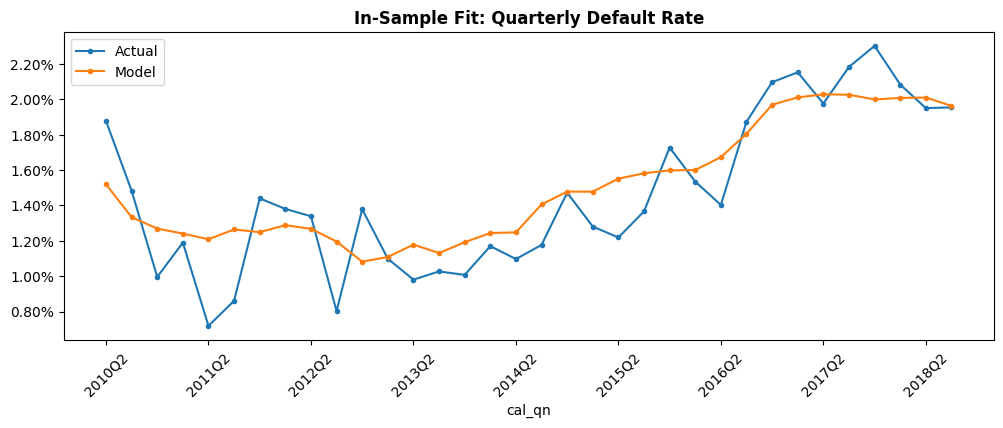

In [ ]:
print("--- Estimating the Hazard Models ---")

def fit_logit_irls(X, y, max_iter=100, tol=1e-9, ridge=1e-8):
    """Logistic regression by Newton-Raphson (IRLS) with robust standard errors (see Part 3)."""
    X = np.asarray(X, float); y = np.asarray(y, float)
    k = X.shape[1]
    beta = np.zeros(k); beta[0] = logit(np.clip(y.mean(), 1e-6, 1 - 1e-6))
    def loglik(b):
        mu = np.clip(expit(X @ b), 1e-12, 1 - 1e-12)
        return np.sum(y * np.log(mu) + (1 - y) * np.log(1 - mu))
    ll_old = loglik(beta)
    for it in range(max_iter):
        mu = expit(X @ beta)
        step = np.linalg.solve((X * (mu * (1 - mu))[:, None]).T @ X + ridge * np.eye(k), X.T @ (y - mu))
        t = 1.0
        while loglik(beta + t * step) < ll_old - 1e-10 and t > 1e-4:
            t /= 2
        beta = beta + t * step
        ll_new = loglik(beta)
        if np.max(np.abs(t * step)) < tol or abs(ll_new - ll_old) < tol:
            break
        ll_old = ll_new
    mu = expit(X @ beta)
    A_inv = np.linalg.inv((X * (mu * (1 - mu))[:, None]).T @ X + ridge * np.eye(k))
    score = X * (y - mu)[:, None]
    return {'beta': beta, 'se_robust': np.sqrt(np.diag(A_inv @ (score.T @ score) @ A_inv)), 'n_iter': it + 1}

def predict_logit(fit, X):
    return expit(np.asarray(X, float) @ fit['beta'])

class Design:
    """Imputes, standardizes and one-hot encodes using training-set statistics (see Part 3)."""
    def __init__(self, frame, num, cat, min_count=200):
        self.num, self.cat = num, cat
        self.median = frame[num].median()
        filled = frame[num].fillna(self.median)
        self.mean, self.std = filled.mean(), filled.std().replace(0, 1)
        self.levels = {}
        for c in cat:
            counts = frame[c].fillna('missing').value_counts()
            self.levels[c] = counts[counts >= min_count].index.tolist()[1:]
    def transform(self, frame):
        Z = (frame[self.num].fillna(self.median) - self.mean) / self.std
        parts = [pd.Series(1.0, index=frame.index, name='const'), Z]
        for c, lv in self.levels.items():
            col = frame[c].fillna('missing')
            parts.append(pd.DataFrame({f'{c}={l}': (col == l).astype(float) for l in lv}, index=frame.index))
        return pd.concat(parts, axis=1)

def fit_hazard(frame, num, cat, target):
    design = Design(frame, num, cat, min_count=0)
    X = design.transform(frame)
    return design, fit_logit_irls(X, frame[target].values), X.columns

MACRO_VARS = ['ur_lag', 'dur4_lag', 'gdp_lag']
DEF_NUM = ['fico', 'dti', 'log_annual_inc', 'revol_util', 'term_60'] + MACRO_VARS
DEF_CAT = ['grade', 'home_ownership', 'age_b']
PRE_NUM = ['fico', 'dti', 'log_annual_inc', 'int_rate', 'term_60']
PRE_CAT = ['grade', 'age_b']

# 1. Fit the default and prepayment hazards
def_design, def_fit, def_cols = fit_hazard(panel, DEF_NUM, DEF_CAT, 'd_default')
pre_design, pre_fit, pre_cols = fit_hazard(panel, PRE_NUM, PRE_CAT, 'd_prepay')
print(f"Default hazard converged in {def_fit['n_iter']} iterations; prepayment hazard in {pre_fit['n_iter']}")

# 2. Coefficient table
z = def_fit['beta'] / def_fit['se_robust']
coef_df = pd.DataFrame({'Coefficient': def_fit['beta'], 'Robust SE': def_fit['se_robust'],
                        'p-value': 2 * stats.norm.sf(np.abs(z)), 'Odds Ratio': np.exp(def_fit['beta'])},
                       index=def_cols)
coef_df['Odds Ratio per Unit'] = np.exp(coef_df['Coefficient'] / def_design.std.reindex(def_cols))
print("\n--- Default Hazard Coefficients ---")
display(coef_df.round(4))

# 3. Sign check
print("--- Sign Check (Economic Intuition) ---")
expected_signs = {'ur_lag': +1, 'dur4_lag': +1, 'gdp_lag': -1, 'fico': -1, 'dti': +1, 'term_60': +1}
for var, sign in expected_signs.items():
    ok = np.sign(coef_df.loc[var, 'Coefficient']) == sign
    print(f"{'OK  ' if ok else 'FLAG'}  {var:9s} coef = {coef_df.loc[var, 'Coefficient']:+.4f} "
          f"(p = {coef_df.loc[var, 'p-value']:.3f}), expected {'+' if sign > 0 else '-'}")

# 4. In-sample fit: quarterly default rate, actual vs. model
panel['hazard_hat'] = predict_logit(def_fit, def_design.transform(panel))
fit_q = panel.groupby('cal_qn').agg(Actual=('d_default', 'mean'), Model=('hazard_hat', 'mean'), n=('d_default', 'size'))
fit_q = fit_q[fit_q['n'] >= 500]
ax = fit_q[['Actual', 'Model']].plot(figsize=(12, 4), marker='.')
ax.set_xticks(fit_q.index[::4]); ax.set_xticklabels([qlabel(q) for q in fit_q.index[::4]], rotation=45)
ax.set_title('In-Sample Fit: Quarterly Default Rate', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2%}'))
plt.show()

## Conclusion:
1. **Borrower risk and seasoning are well estimated.**
   * **Grade:** the default odds rise monotonically from grade A (0.48× the reference grade B) to grade G (5.84×).
   * **Borrower risk:** higher FICO (−0.4% odds per point) and lower DTI (+0.4% per point) behave as expected.
   * **Seasoning:** the age coefficients reproduce the curve from Step 2. The odds in quarter 1 are 0.05× those of the peak ages (5–6 quarters).

2. **The macro coefficients fail the sign check.** Only 3 of the 6 checks pass (`dur4_lag`, `fico`, `dti`).
   * **`ur_lag` (FLAG, significant):** +1 pp of unemployment *lowers* the default odds by 4.7% (odds ratio 0.953). That is economically implausible.
   * **`dur4_lag` (OK):** a *rising* unemployment rate raises the odds by **8.9% per pp** of 4-quarter change. This is the only macro variable that behaves as expected.
   * **`gdp_lag` (FLAG, not significant):** no measurable effect.
   * **`term_60` (FLAG):** with grade held fixed, 60-month loans show *lower* default odds. Lending Club already charges 60-month loans higher grades, so the grade dummies absorb their extra risk.

3. **Diagnosis: omitted vintage effect.** Between 2010 and 2018, unemployment fell every year while Lending Club's new vintages became riskier. The model has no variable for underwriting quality, so it attributes the rising defaults to the falling unemployment. That is a textbook case of **omitted-variable bias**. The fix is to add vintage (issue-year) effects, or to identify the macro effect only from differences between states.

4. **In-sample fit looks good, but it is misleading.** The model follows the rise of the quarterly default rate from about 1.2% (2012–2014) to about 2.0% (2017–2018). It reproduces the trend, but for the wrong reason.

# Step 4: Out-of-Time Backtest
A good in-sample fit is easy to achieve. The real test is whether a model estimated on the past predicts the **future** default rate when it is fed the macro path that actually happened. This is how a model validator would challenge a stress-testing model:

1. Re-estimate the hazard model using only quarters up to `BT_END`, 8 quarters before the end of the panel.
2. Predict the default hazard of every loan-quarter in the following 8 quarters, using the actual macro data.
3. Compare predicted and actual quarterly default rates.

The same test is run for a **benchmark model without macro variables**. If the macro model does not beat it, the macro link adds no forecasting value. That would be an important validation finding.

--- Out-of-Time Backtest ---
Estimated up to 2016Q3, predicted 2016Q4 to 2018Q3


,Mean Abs. Error (pp),Predicted / Actual Defaults
With Macro,0.3352,0.8401
No Macro (Benchmark),0.3319,0.8419


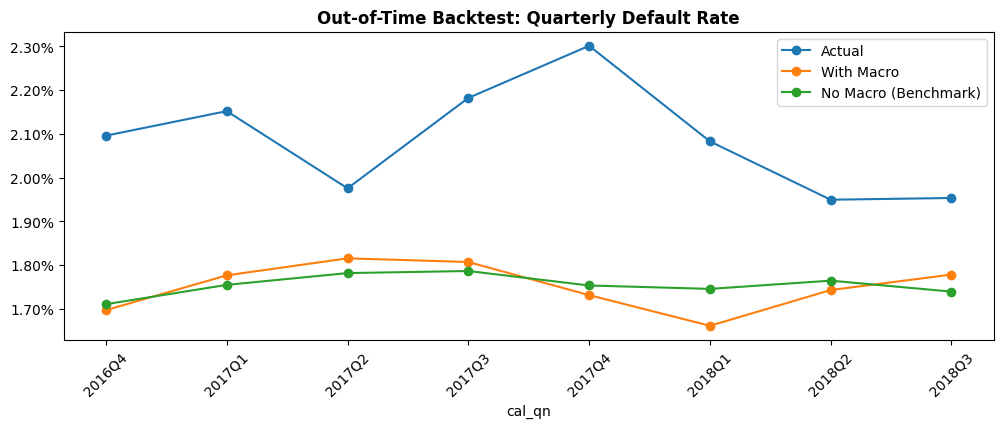

In [ ]:
print("--- Out-of-Time Backtest ---")
BT_END = END_QN - BACKTEST_Q
bt_train = panel[panel['cal_qn'] <= BT_END]
bt_test = panel[panel['cal_qn'] > BT_END].copy()

backtest_models = {'With Macro': DEF_NUM, 'No Macro (Benchmark)': [v for v in DEF_NUM if v not in MACRO_VARS]}
for name, num_vars in backtest_models.items():
    d_bt, f_bt, _ = fit_hazard(bt_train, num_vars, DEF_CAT, 'd_default')
    bt_test[name] = predict_logit(f_bt, d_bt.transform(bt_test))

bt_q = bt_test.groupby('cal_qn')[['d_default'] + list(backtest_models)].mean().rename(columns={'d_default': 'Actual'})
bt_errors = pd.DataFrame({name: {'Mean Abs. Error (pp)': 100 * np.mean(np.abs(bt_q[name] - bt_q['Actual'])),
                                 'Predicted / Actual Defaults': bt_test[name].sum() / bt_test['d_default'].sum()}
                          for name in backtest_models}).T
print(f"Estimated up to {qlabel(BT_END)}, predicted {qlabel(BT_END + 1)} to {qlabel(END_QN)}")
display(bt_errors.round(4))

ax = bt_q.plot(figsize=(12, 4), marker='o')
ax.set_xticks(bt_q.index); ax.set_xticklabels([qlabel(q) for q in bt_q.index], rotation=45)
ax.set_title('Out-of-Time Backtest: Quarterly Default Rate', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2%}'))
plt.show()

## Conclusion:
1. **Both models miss the level.** From 2016Q4 to 2018Q3, the actual quarterly default rate was **1.95–2.30%**. Both models predicted only **1.66–1.82%**, so total predicted defaults are **84%** of actual defaults, a **16% under-prediction**. The models were estimated on older, safer vintages and cannot anticipate the riskier 2016–2017 vintages. This is the same vintage problem, seen out of time.

2. **The macro variables add nothing.** The mean absolute error is **0.335 pp** with macro variables and **0.332 pp** without. The macro model is slightly *worse*, and its predictions also move in the wrong direction in 2018Q1.

3. **Validation verdict.** A model validator would rate this PD satellite model **"not fit for purpose" for scenario analysis**. Three findings support this: the macro level effect has the wrong sign, the macro variables add no forecasting power, and the model under-predicts defaults by 16%. The following steps still run the full stress-testing machinery, because the engine itself (scenarios, downscaling, amortization, LGD link) is correct. But the scenario *sensitivity* it produces must be read with this verdict in mind.

# Step 5: Scenario Design & Regional Downscaling
Three stylized national scenarios are defined over 9 quarters, starting from the actual values at the snapshot date:

| Scenario | Unemployment | Real GDP growth (annualized) | Narrative |
|---|---|---|---|
| **Baseline** | stays at the starting level | +2% | steady expansion |
| **Adverse** | rises by 3 pp, peaks after about 5 quarters | dips to −1.5% | mild recession |
| **Severely Adverse** | rises to **10%**, peaks after about 5 quarters | falls to −6% | deep recession, similar in size to 2008–09 |

The severely adverse path matches the headline of the Federal Reserve's 2025 supervisory scenario. There, unemployment rises from 4.1% to a peak of 10% and real GDP falls 7.8% peak-to-trough. A scenario must tell a **coherent story**: unemployment and GDP move together.

If the macro data extends beyond the snapshot date, a fourth, **"Realized Path"** scenario uses the macro data that actually followed. For a 2019 snapshot, that is the **COVID-19 shock of 2020**, when US unemployment jumped to about 15% within weeks. The macro shock was *more* severe than our severely adverse scenario, yet actual consumer-credit losses in 2020–21 stayed low. Payment deferrals, stimulus checks and enhanced unemployment benefits broke the historical link between unemployment and default. This scenario therefore shows **model risk under a structural break**.

National paths are downscaled to states with each state's estimated beta (see the Algorithm Logic Review).

--- Scenario Design ---
Least cyclical states: {'ND': 0.24, 'AK': 0.38, 'NE': 0.38}
Most cyclical states:  {'OR': 1.18, 'NC': 1.26, 'MI': 1.39}
Realized macro path available -> added as a 4th scenario


,Baseline,Adverse,Severely Adverse,Realized Path
2019Q2,3.87,4.62,5.40,3.63
2019Q3,3.87,5.37,6.93,3.60
2019Q4,3.87,6.12,8.47,3.60
2020Q1,3.87,6.57,9.39,3.83
2020Q2,3.87,6.87,10.00,13.00
2020Q3,3.87,6.87,10.00,8.80
2020Q4,3.87,6.72,9.69,6.77
2021Q1,3.87,6.57,9.39,6.23
2021Q2,3.87,6.42,9.08,5.93


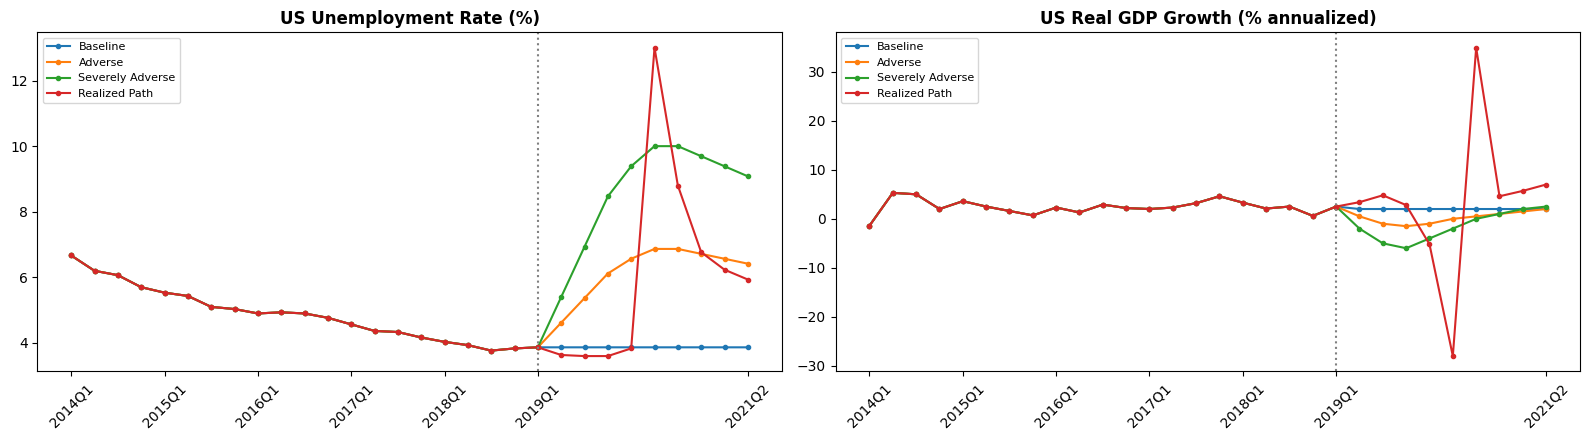

In [ ]:
print("--- Scenario Design ---")

# 1. National scenario paths
hist_us = macro_us[macro_us['qn'] <= AS_OF_QN].set_index('qn')
u0 = hist_us.loc[AS_OF_QN, 'ur_us']
shape = np.array([0.25, 0.50, 0.75, 0.90, 1.00, 1.00, 0.95, 0.90, 0.85])   # timing of the shock
GDP_BASE = np.full(H, 2.0)
GDP_ADV = np.array([0.5, -1.0, -1.5, -1.0, 0.0, 0.5, 1.0, 1.5, 2.0])
GDP_SEV = np.array([-2.0, -5.0, -6.0, -4.0, -2.0, 0.0, 1.0, 2.0, 2.5])

def us_scenario(peak_ur):
    """Unemployment path to a given peak; GDP scaled between baseline and severe accordingly."""
    k = np.clip((peak_ur - u0) / max(10.0 - u0, 1e-6), 0, None)
    return {'ur_us': u0 + (peak_ur - u0) * shape, 'gdp_growth': GDP_BASE + k * (GDP_SEV - GDP_BASE)}

SCENARIOS = {
    'Baseline': {'ur_us': np.full(H, u0), 'gdp_growth': GDP_BASE},
    'Adverse': {'ur_us': u0 + 3.0 * shape, 'gdp_growth': GDP_ADV},
    'Severely Adverse': {'ur_us': u0 + (10.0 - u0) * shape, 'gdp_growth': GDP_SEV},
}
proj_q = np.arange(AS_OF_QN + 1, AS_OF_QN + H + 1)

# 2. State betas: sensitivity of each state's unemployment to the national cycle
hist_state = macro_state[macro_state['qn'] <= AS_OF_QN]
state_wide = hist_state.pivot(index='qn', columns='state', values='ur').sort_index()
d_us = hist_us['ur_us'].reindex(state_wide.index).diff()
state_beta = {}
for s in state_wide.columns:
    d_s = state_wide[s].diff()
    m = d_s.notna() & d_us.notna()
    state_beta[s] = float((d_s[m] * d_us[m]).sum() / (d_us[m] ** 2).sum())   # OLS through the origin
state_beta = pd.Series(state_beta).sort_values()
print(f"Least cyclical states: {state_beta.head(3).round(2).to_dict()}")
print(f"Most cyclical states:  {state_beta.tail(3).round(2).to_dict()}")

# 3. Build a macro cube (history + projection) for each scenario
def build_cube(us_path):
    ur_T = state_wide.loc[AS_OF_QN]
    rows = []
    for h, q in enumerate(proj_q):
        ur_s = (ur_T + state_beta.reindex(ur_T.index).fillna(1.0) * (us_path['ur_us'][h] - u0)).clip(lower=2.0)
        rows.append(pd.DataFrame({'state': ur_s.index, 'qn': q, 'ur': ur_s.values,
                                  'gdp_growth': us_path['gdp_growth'][h], 'ur_us': us_path['ur_us'][h]}))
    hist = hist_state[['state', 'qn', 'ur']].merge(hist_us[['gdp_growth', 'ur_us']], left_on='qn', right_index=True)
    full = pd.concat([hist, *rows], ignore_index=True).sort_values(['state', 'qn'])
    full['ur_chg4'] = full.groupby('state')['ur'].diff(4)
    return MacroCube(full)

cubes = {name: build_cube(path) for name, path in SCENARIOS.items()}

# 4. Realized path (only if the macro data covers the full horizon)
if set(proj_q) <= (set(macro_us['qn']) & set(macro_state['qn'])):
    cubes['Realized Path'] = MacroCube(macro_all)
    realized = macro_us.set_index('qn').loc[proj_q]
    SCENARIOS['Realized Path'] = {'ur_us': realized['ur_us'].values, 'gdp_growth': realized['gdp_growth'].values}
    print("Realized macro path available -> added as a 4th scenario")

display(pd.DataFrame({k: v['ur_us'] for k, v in SCENARIOS.items()}, index=[qlabel(q) for q in proj_q]).round(2))

# 5. Plot the scenarios
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
hq = hist_us.index[hist_us.index >= AS_OF_QN - 20]
for name, path in SCENARIOS.items():
    for ax, var in zip(axes, ['ur_us', 'gdp_growth']):
        ax.plot(list(hq) + list(proj_q), list(hist_us.loc[hq, var]) + list(path[var]), marker='.', label=name)
for ax, title in zip(axes, ['US Unemployment Rate (%)', 'US Real GDP Growth (% annualized)']):
    ax.axvline(AS_OF_QN, color='grey', ls=':')
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=8)
    ticks = list(hq[::4]) + [proj_q[-1]]
    ax.set_xticks(ticks); ax.set_xticklabels([qlabel(q) for q in ticks], rotation=45)
plt.tight_layout(); plt.show()

## Conclusion:
1. **Scenario severity.**
   * **Starting point:** US unemployment of 3.87% (2019Q1).
   * **Adverse:** peaks at **6.87%**.
   * **Severely adverse:** peaks at **10.0%** in 2020Q2–Q3. Its GDP path falls to −6%.
   * **Realized path:** stayed near 3.6% until 2020Q1, then jumped to **13.0%** (2020Q2 quarterly average) and fell back to 5.9% by 2021Q2. This shock was deeper but much shorter than our severe scenario.

2. **Regional amplification.** State betas range from **0.24 (North Dakota)** to **1.39 (Michigan)**. Alaska and Nebraska are also among the least cyclical states; Oregon and North Carolina among the most cyclical. A +6 pp national shock therefore becomes about +1.5 pp in North Dakota but +8.4 pp in Michigan. The downscaling concentrates the stress on the portfolio's exposure to cyclical states.

# Step 6: Loss Projection Engine
**Starting portfolio.** The starting portfolio contains all loans with status *Current* and a positive balance at the snapshot date. Delinquent loans are already on their way to default. A bank would provision for them separately, as an IFRS 9 Stage 3 style exposure, so their balance is reported but excluded from the projection.

**Static balance sheet.** We make the standard stress-test assumption of a static balance sheet: no new loans are originated, and existing loans run off through scheduled amortization, prepayment and default.

**The projection loop.** For each quarter $h = 1, \dots, 9$ the engine:
1. ages every loan by one quarter;
2. looks up the scenario's lagged state macro variables;
3. computes the default and prepayment hazards;
4. computes the marginal default probability $S_{t-1} h^D_t$;
5. multiplies it by EAD (the scheduled balance) and by LGD (the Part 3 satellite model at the state unemployment rate of that quarter);
6. updates survival.

Two separate macro inputs, one for PD and one for LGD, allow the PD-vs-LGD decomposition in Step 7.

In [ ]:
print("--- Preparing the Starting Portfolio ---")

# 1. Current loans at the snapshot date
port = loan_features(lc[lc['outcome'].eq('current') & (lc['out_prncp'] > 0)])
port = port[port['addr_state'].isin(STATES)].reset_index(drop=True)
START_BAL = port['out_prncp'].sum()
delinquent_bal = lc.loc[lc['outcome'].eq('delinquent'), 'out_prncp'].sum()
print(f"Projected portfolio: {len(port):,} current loans, balance ${START_BAL / 1e6:,.1f}M")
print(f"Excluded delinquent balance: ${delinquent_bal / 1e6:,.1f}M")

# 2. Scheduled amortization -> EAD at the start of each projection quarter
as_of_mn = AS_OF.year * 12 + AS_OF.month
remaining_m = (port['term_m'] - (as_of_mn - (port['issue_m'].dt.year * 12 + port['issue_m'].dt.month))).clip(lower=1).values
r_month = port['int_rate'].values / 1200
B = np.zeros((len(port), 3 * H + 1)); B[:, 0] = port['out_prncp'].values
for m in range(1, 3 * H + 1):
    B[:, m] = np.where(m < remaining_m, np.maximum(B[:, m - 1] * (1 + r_month) - port['installment'].values, 0), 0)
EAD = B[:, 0:3 * H:3]   # EAD[:, h-1] = balance at the start of quarter h

# 3. LGD from the Part 3 satellite model (floored at the long-run average)
alpha = pd.Series(lgd_sat['alpha_by_grade']); lra = pd.Series(lgd_sat['lra_by_grade'])
gamma_eff = lgd_sat['gamma_ur'] if (lgd_sat['gamma_ur'] > 0 and lgd_sat['gamma_p_value'] < 0.10) else 0.0
alpha_i = port['grade'].map(alpha).fillna(alpha.mean()).values
lra_i = port['grade'].map(lra).fillna(lgd_sat['lra_default_weighted']).values
print(f"LGD sensitivity to unemployment used: gamma = {gamma_eff:.4f}")

def lgd_fn(ur):
    return np.maximum(expit(alpha_i + gamma_eff * ur), lra_i)

# 4. The projection engine
BASE_COLS = ['grade', 'home_ownership', 'fico', 'dti', 'log_annual_inc', 'revol_util', 'int_rate', 'term_60', 'addr_state']

def project(cube_pd, cube_lgd):
    """9-quarter projection. cube_pd drives the default hazard; cube_lgd drives LGD."""
    survival = np.ones(len(port)); loan_loss = np.zeros(len(port)); rows = []
    for h, q in enumerate(proj_q, start=1):
        fr = port[BASE_COLS].copy()
        fr['age'] = (AS_OF_QN - port['issue_qn'].values) + h
        fr['age_b'] = age_bucket(fr['age'])
        fr['cal_qn'] = q
        fr = add_macro(fr, cube_pd)
        h_def = predict_logit(def_fit, def_design.transform(fr))
        h_pre = predict_logit(pre_fit, pre_design.transform(fr))
        ead = EAD[:, h - 1]; alive = ead > 0
        lgd = lgd_fn(cube_lgd.get('ur', port['addr_state'].values, np.full(len(port), q)))
        pd_marginal = survival * h_def * alive
        loss = pd_marginal * ead * lgd
        loan_loss += loss
        rows.append({'Quarter': qlabel(q), 'Expected Defaults': pd_marginal.sum(),
                     'Defaulted Balance': (pd_marginal * ead).sum(), 'Loss': loss.sum(),
                     'Avg Hazard': np.average(h_def, weights=survival * ead + 1e-12)})
        survival = np.clip(survival * (1 - h_def - h_pre), 0, 1) * alive
    out = pd.DataFrame(rows).set_index('Quarter')
    out['Cumulative Loss'] = out['Loss'].cumsum()
    return out, loan_loss

print("Projection engine ready.")

--- Preparing the Starting Portfolio ---
Projected portfolio: 873,780 current loans, balance $9,125.8M
Excluded delinquent balance: $384.2M
LGD sensitivity to unemployment used: gamma = 0.0422
Projection engine ready.


# Step 7: Stress Test Results
We now run the engine under every scenario and analyze the results from three angles:

1. **Scenario losses.** The 9-quarter loss rate, the cumulative PD, the implied LGD, and the quarterly loss path.
2. **PD vs. LGD decomposition.** The severely adverse scenario is re-run twice: once with only the PD channel stressed (LGD at baseline), and once with only the LGD channel stressed. The part left over is the **interaction**: defaults rise *and* each default loses more.
3. **Loss by grade.** Where the stress loss is concentrated.

--- Running the Stress Test ---

--- Scenario Summary ---


,9Q Loss ($M),9Q Loss Rate,Cumulative PD,Implied LGD,Peak Quarterly Hazard,x Baseline
Baseline,868.1621,0.0951,0.1044,0.9116,0.0250,1.0000
Adverse,876.7774,0.0961,0.1051,0.9142,0.0264,1.0099
Severely Adverse,888.2349,0.0973,0.1058,0.9202,0.0281,1.0231
Realized Path,922.5275,0.1011,0.1104,0.9158,0.0428,1.0626


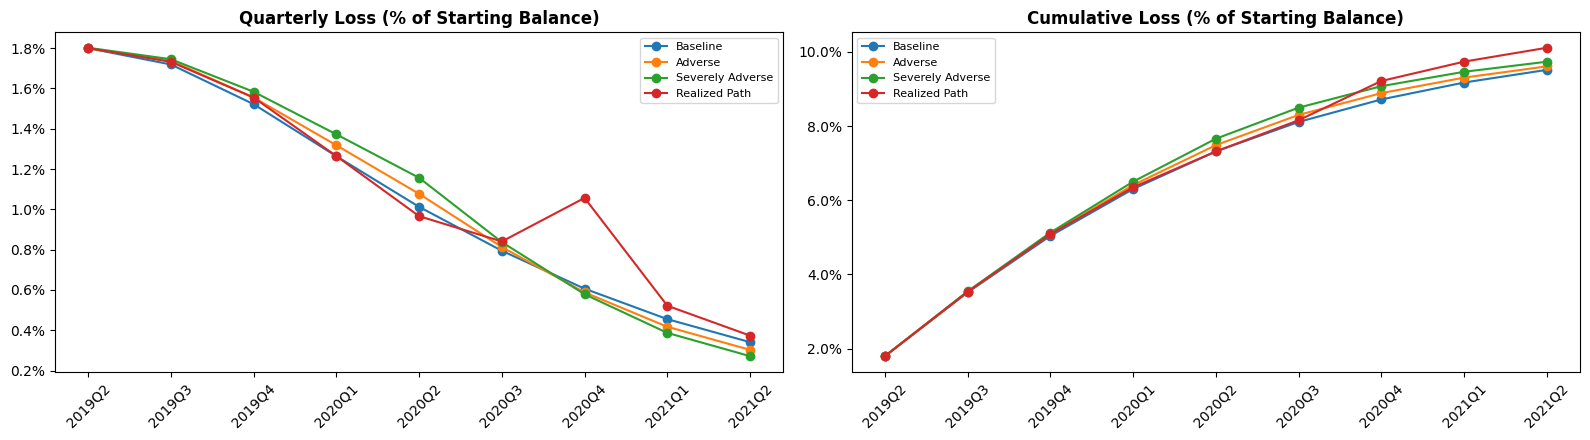


--- Decomposition of the Severely Adverse Loss ($M) ---


,$M
Baseline Loss,868.16
+ PD Channel,11.82
+ LGD Channel,8.06
+ Interaction,0.20
Severely Adverse Loss,888.23


Share of the stress add-on explained by PD: 59%

--- 9-Quarter Loss Rate by Grade ---


,Baseline,Adverse,Severely Adverse,Realized Path,Balance Share
grade,,,,,
A,0.0289,0.0293,0.0298,0.0307,0.2170
B,0.0645,0.0652,0.0662,0.0688,0.2850
C,0.1120,0.1131,0.1145,0.1193,0.2973
D,0.1665,0.1680,0.1700,0.1770,0.1400
E,0.2080,0.2099,0.2124,0.2193,0.0454
F,0.2790,0.2812,0.2842,0.2923,0.0116
G,0.3236,0.3261,0.3294,0.3370,0.0038


In [ ]:
print("--- Running the Stress Test ---")

# 1. Losses by scenario
projections, loan_losses = {}, {}
for name in SCENARIOS:
    projections[name], loan_losses[name] = project(cubes[name], cubes[name])

summary = pd.DataFrame({
    name: {'9Q Loss ($M)': p['Loss'].sum() / 1e6,
           '9Q Loss Rate': p['Loss'].sum() / START_BAL,
           'Cumulative PD': p['Defaulted Balance'].sum() / START_BAL,
           'Implied LGD': p['Loss'].sum() / p['Defaulted Balance'].sum(),
           'Peak Quarterly Hazard': p['Avg Hazard'].max()}
    for name, p in projections.items()}).T
summary['x Baseline'] = summary['9Q Loss Rate'] / summary.loc['Baseline', '9Q Loss Rate']
print("\n--- Scenario Summary ---")
display(summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for name, p in projections.items():
    axes[0].plot(p.index, p['Loss'] / START_BAL, marker='o', label=name)
    axes[1].plot(p.index, p['Cumulative Loss'] / START_BAL, marker='o', label=name)
axes[0].set_title('Quarterly Loss (% of Starting Balance)', fontweight='bold')
axes[1].set_title('Cumulative Loss (% of Starting Balance)', fontweight='bold')
for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 2. PD vs. LGD decomposition of the severely adverse add-on
base_loss = projections['Baseline']['Loss'].sum()
severe_loss = projections['Severely Adverse']['Loss'].sum()
pd_only = project(cubes['Severely Adverse'], cubes['Baseline'])[0]['Loss'].sum()
lgd_only = project(cubes['Baseline'], cubes['Severely Adverse'])[0]['Loss'].sum()
decomposition = pd.Series({'Baseline Loss': base_loss,
                           '+ PD Channel': pd_only - base_loss,
                           '+ LGD Channel': lgd_only - base_loss,
                           '+ Interaction': severe_loss - pd_only - lgd_only + base_loss,
                           'Severely Adverse Loss': severe_loss}) / 1e6
pd_share = (pd_only - base_loss) / (severe_loss - base_loss)
print("\n--- Decomposition of the Severely Adverse Loss ($M) ---")
display(decomposition.to_frame('$M').round(2))
print(f"Share of the stress add-on explained by PD: {pd_share:.0%}")

# 3. Loss rate by grade
by_grade = pd.DataFrame({name: pd.Series(ll).groupby(port['grade']).sum() / port.groupby('grade')['out_prncp'].sum()
                         for name, ll in loan_losses.items()})
by_grade['Balance Share'] = port.groupby('grade')['out_prncp'].sum() / START_BAL
print("\n--- 9-Quarter Loss Rate by Grade ---")
display(by_grade.round(4))

## Conclusion:
1. **Scenario losses barely differ.**
   * **Baseline:** 9-quarter loss of **$868M, 9.51%** of the $9.13bn starting balance (cumulative PD 10.4%, implied LGD 91.2%).
   * **Adverse:** 9.61% (1.01×).
   * **Severely adverse:** 9.73% (1.02×), only **$20M** more than baseline.
   * **Realized path:** 10.11% (1.06×).

   For comparison, in the Fed's 2025 stress test the severely adverse 9-quarter loss rate for bank credit cards was 16.9%, and consumer losses rose sharply in 2008–09. A 2% increase for a doubling of unemployment is **not credible**. It is the direct consequence of the wrong-signed coefficient in Step 3.

2. **The quarterly path shows the flaw.** In the severe scenario, losses first exceed baseline while unemployment is *rising*: the positive `dur4_lag` momentum effect dominates. From 2020Q4, once unemployment stays high, severe-scenario losses fall *below* baseline, because the negative `ur_lag` level effect takes over. In other words, the model predicts that a *sustained* 10% unemployment rate reduces defaults. The realized path shows the same mechanics: a loss spike in 2020Q4 (1.06% of the balance in one quarter) two quarters after the unemployment jump, then a fast return.

3. **PD vs. LGD decomposition.** Of the $20.1M stress add-on, the **PD channel contributes 59%** ($11.8M), the **LGD channel 40%** ($8.1M, from the Part 3 satellite model) and the interaction 1%. The LGD channel works as designed. The PD channel is the one that is too weak.

4. **Concentration by grade.** The baseline loss rate rises from **2.9% (A)** to **32.4% (G)**. In dollars, the loss is concentrated in the middle grades. Grade C (29.7% of the balance, 11.2% loss rate) causes about 35% of the total loss, and grade D (14.0%, 16.7%) about 25%. Together, C and D carry **60% of the loss on 44% of the balance**. Grades F and G are very risky but make up only 1.5% of the book.

5. **Realized path.** The model projects a 10.1% loss under the actual 2019–21 path, only slightly above baseline. The model's weak macro sensitivity cannot be tested against this episode, because in 2020–21 payment deferrals and government support broke the normal link between unemployment and default across consumer credit.

# Step 8: Sensitivity Analysis & Reverse Stress Test
The three scenarios give three points. A **sensitivity curve** gives the whole picture: the projection is re-run for a grid of peak unemployment rates, with GDP scaled consistently.

A **reverse stress test** reads the curve backwards. Instead of asking *"what is the loss in scenario X?"*, it asks *"which scenario produces an unacceptable loss?"*. Here the unacceptable outcome is defined as **double the baseline loss**. In a bank, the threshold would be the loss that exhausts the capital buffer above the regulatory minimum.

--- Sensitivity Curve (this re-runs the projection ~11 times) ---


,9Q Loss Rate
Peak US Unemployment (%),
4.0,0.0952
5.0,0.0954
6.0,0.0956
7.0,0.0960
8.0,0.0964
9.0,0.0969
10.0,0.0973
11.0,0.0978
12.0,0.0983



Reverse Stress Test: Doubling the baseline loss (19.03%) requires unemployment above 14%.


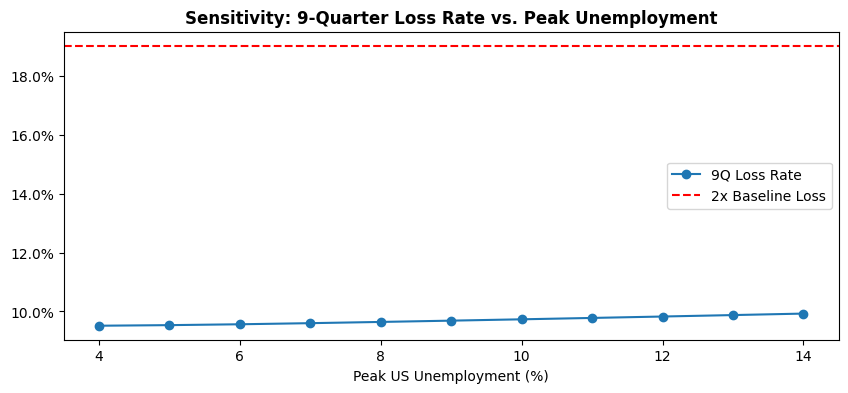

In [ ]:
print("--- Sensitivity Curve (this re-runs the projection ~11 times) ---")

peaks = np.arange(np.ceil(u0), 15.0, 1.0)
sensitivity = pd.Series({pk: project(build_cube(us_scenario(pk)), build_cube(us_scenario(pk)))[0]['Loss'].sum() / START_BAL
                         for pk in peaks}, name='9Q Loss Rate')
sensitivity.index.name = 'Peak US Unemployment (%)'
display(sensitivity.to_frame().round(4))

# Reverse stress test: which unemployment peak doubles the baseline loss?
target = 2 * summary.loc['Baseline', '9Q Loss Rate']
if sensitivity.max() >= target and sensitivity.is_monotonic_increasing:
    ur_star = np.interp(target, sensitivity.values, sensitivity.index.values)
    reverse_msg = f"A peak unemployment rate of about {ur_star:.1f}% doubles the baseline loss ({target:.2%})."
else:
    reverse_msg = f"Doubling the baseline loss ({target:.2%}) requires unemployment above {peaks[-1]:.0f}%."
print(f"\nReverse Stress Test: {reverse_msg}")

ax = sensitivity.plot(marker='o', figsize=(10, 4))
ax.axhline(target, color='red', ls='--', label='2x Baseline Loss')
ax.set_title('Sensitivity: 9-Quarter Loss Rate vs. Peak Unemployment', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}')); ax.legend()
plt.show()

## Conclusion:
1. **Sensitivity.** The 9-quarter loss rate rises from **9.52%** at a 4% unemployment peak to **9.93%** at 14%. That is only **+0.04 pp per point** of peak unemployment, and the curve is almost perfectly linear. There is no sign of the convex "cliff" that consumer portfolios show in real recessions.

2. **Reverse stress test.** Doubling the baseline loss (to 19.0%) would require unemployment **above 14%**, beyond the grid. The US reached about 10% in 2009 and about 13% (quarterly average) in 2020. Taken at face value, this portfolio could not be broken by any historical recession, which confirms that the model's macro sensitivity is far too low. **A reverse stress test that finds no plausible breaking point is itself a red flag** in model validation.

# Executive Summary

This project built a bottom-up macroeconomic stress test for **873,780 current Lending Club loans ($9.13bn outstanding)**. It projected credit losses over 9 quarters under baseline, adverse and severely adverse scenarios, and under the realized 2019–21 macro path. The engine works, but the validation shows that the PD satellite model **understates macroeconomic sensitivity**. The main lesson of the project is therefore a model-risk finding.

## Model Design

* **PD:** a discrete-time hazard model on **849,045 loan-quarters** (15,218 defaults), with seasoning, borrower risk and lagged state unemployment and GDP, plus a competing prepayment hazard.
* **LGD:** the Part 3 satellite model (+0.34 pp LGD per pp of unemployment), floored at the 91% long-run average.
* **EAD:** the scheduled amortization of each loan's current balance.
* **Scenarios:** national paths downscaled to states with estimated state betas (0.24–1.39).

## Stress Test Results

| Scenario | Peak Unemployment | 9Q Loss ($M) | 9Q Loss Rate | × Baseline |
| --- | --- | --- | --- | --- |
| Baseline | 3.9% | 868 | 9.51% | 1.00 |
| Adverse | 6.9% | 877 | 9.61% | 1.01 |
| Severely Adverse | 10.0% | 888 | 9.73% | 1.02 |
| Realized Path (2019–21) | 13.0% | 923 | 10.11% | 1.06 |

> **Key Takeaway:** Grade drives the risk: loss rates range from 2.9% (A) to 32.4% (G), and grades C and D carry 60% of the dollar loss. The macroeconomy barely moves the projection. Of the small stress add-on, 59% comes from PD and 40% from LGD. That result reflects a **model limitation, not portfolio resilience**.

---

## Model Validation

* **Sign check:** **3/6** expected signs confirmed. Unemployment level (significant, wrong sign), GDP (not significant) and the 60-month term (absorbed by grade) are flagged.
* **Out-of-time backtest (2016Q4–2018Q3):** mean absolute error of **0.335 pp** with macro variables vs. **0.332 pp** without. Both models under-predict defaults by **16%**.
* **Root cause:** omitted vintage effect. Underwriting loosened (default share 14% → 23%) while unemployment fell (10% → 4%), so the model attributes the rising defaults to falling unemployment.
* **Verdict:** not fit for scenario analysis without remediation. The scenario losses are a **lower bound**.

## Remediation Plan

1. **Add vintage (issue-year) effects**, so that the macro coefficients are identified from calendar-time variation *within* each vintage.
2. **Add state fixed effects**, or use only the change in unemployment (`dur4_lag`), which already has the expected sign (+8.9% odds per pp).
3. **Management overlay** (interim): scale the stressed hazard with an external benchmark sensitivity until the remediated model passes the backtest.
4. **Re-run the sign check, the backtest and the reverse stress test** as acceptance criteria.

## Limitations

1. **Weak identification of the macro effect.** 2010–2018 contains no recession, and unemployment moved in one direction only.
2. **Extrapolation.** The scenarios push unemployment beyond most of the estimation sample.
3. **Static balance sheet.** There are no new originations, no management actions and no government relief.
4. **Parameter uncertainty is ignored.** Bootstrapping would give a loss range instead of point estimates.
5. **Prepayment does not react to the economy**, although prepayments usually fall in recessions.